Выполнила: Иванова Дарья, БПМ-23-ПО-2

In [81]:
%pip install -q scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

Загружаем CSV

In [ ]:
df = pd.read_csv("res_2.csv", sep=";")

print(df.head())
print(df.columns)

   Unnamed: 0                  Книга  Глава Склонность к диалогам  \
0           0  Лукьяненко Дозоры.txt      1                     0   
1           1  Лукьяненко Дозоры.txt      2                     0   
2           2  Лукьяненко Дозоры.txt      3           0,222222222   
3           3  Лукьяненко Дозоры.txt      4           0,193396226   
4           4  Лукьяненко Дозоры.txt      5           0,571942446   

  Степень эгоцентризма Сложность предложения Средняя длина предложения  \
0                    0                  0,35               6,666666667   
1                    0           0,046511628               14,33333333   
2          0,001808318           0,197106691               8,991869919   
3          0,031455399           0,189201878               9,508928571   
4          0,040643522           0,103302286               7,731587561   

  Склонность к действию Склонность к описанию деталей Склонность к уклонению  \
0                     0                             0       

Исправляю запятые в числах на точки

In [ ]:
features_columns = [
    'Склонность к диалогам',
    'Степень эгоцентризма',
    'Сложность предложения',
    'Средняя длина предложения',
    'Склонность к действию',
    'Склонность к описанию деталей',
    'Склонность к уклонению',
    'Склонность говорить от 3 лица'
]

for col in features_columns:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

Формируем Х

In [ ]:
X = df[features_columns].values

Кодируем авторов  # Лукьяненко = [1,0]
# Бурков = [0,1]

In [ ]:
y = []

for name in df["Книга"]:
    
    if "Лук" in name:
        y.append([1,0])
    else:
        y.append([0,1])

y = np.array(y)

Разделение на выбрки (70%/30%)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Нормализация

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Строим нейронку с 8 входных прищнаками, для них выделено 24 нейрона скрытого слоя, на выходе 2 выходных нейрона

In [ ]:
class NeuralNetwork:
    
    def __init__(self):
        
        self.W1 = np.random.randn(8,24) * 0.01
        self.b1 = np.zeros((1,24))
        
        self.W2 = np.random.randn(24,2) * 0.01
        self.b2 = np.zeros((1,2))
    
    def sigmoid(self, x):
        return 1/(1+np.exp(-x))
    
    def forward(self, X):
        
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2
    
    def loss(self, y, y_pred):
        return np.mean((y - y_pred)**2)
    
    def train(self, X, y, epochs=2000, lr=0.01):
        
        losses = []
        
        for i in range(epochs):
            
            y_pred = self.forward(X)
            
            loss = self.loss(y, y_pred)
            losses.append(loss)
            
            d2 = (y_pred - y) * y_pred*(1-y_pred)
            d1 = np.dot(d2, self.W2.T) * self.a1*(1-self.a1)
            
            self.W2 -= lr * np.dot(self.a1.T, d2)
            self.b2 -= lr * np.sum(d2, axis=0, keepdims=True)
            
            self.W1 -= lr * np.dot(X.T, d1)
            self.b1 -= lr * np.sum(d1, axis=0, keepdims=True)
        
        return losses


Обучаем

In [ ]:
nn = NeuralNetwork()

losses = nn.train(X_train, y_train)

График ошибок

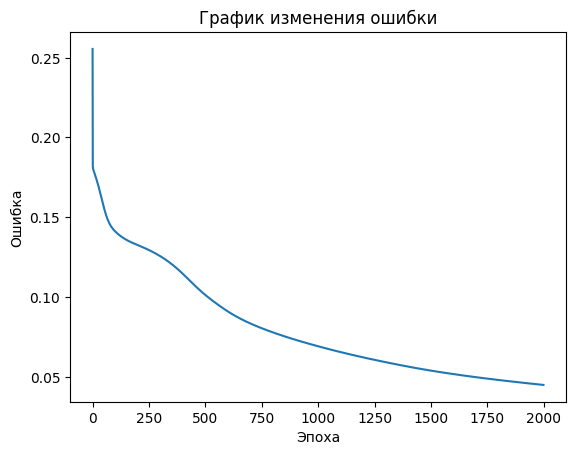

In [ ]:
plt.plot(losses)
plt.title("График изменения ошибки")
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.show()

Тестовая выборка:

In [ ]:
y_pred = nn.forward(X_test)

pred = np.argmax(y_pred, axis=1)
true = np.argmax(y_test, axis=1)

accuracy = np.mean(pred == true)

print("Точность на тестовой выборке:", accuracy)

Точность на тестовой выборке: 0.8818897637795275


Матрица ошибок:

In [ ]:
cm = confusion_matrix(true, pred)

print("\nМатрица ошибок:")
print(cm)


Матрица ошибок:
[[39  7]
 [ 8 73]]


Процент ошибок:

In [ ]:
print("\nОшибка модели:", 1 - accuracy)


Ошибка модели: 0.11811023622047245
